In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [4]:
print("🔍 Loading data for 3-State HMM Regime Detection...")
df_raw = pd.read_parquet('C:/Users/Sam Garcia/PycharmProjects/macro_alpha/data/market_macro_data.parquet')
df_features = pd.read_parquet('C:/Users/Sam Garcia/PycharmProjects/macro_alpha/data/processed/inference_ready_features.parquet')

df = df_features.copy()
df['close'] = df_raw['close_sp500']

# The Emissions (Symptoms)
X_hmm = df[['daily_return', 'volatility_20d']].dropna()

print("🧠 Training 3-State Gaussian HMM...")
# UPGRADE: Ask the math to find 3 distinct market regimes
hmm_model = GaussianHMM(n_components=3, covariance_type="full", n_iter=1000, random_state=42)
hmm_model.fit(X_hmm)

# Predict the hidden states (0, 1, or 2)
df.loc[X_hmm.index, 'regime'] = hmm_model.predict(X_hmm)

# Sort the regimes by Volatility so we know what they mean
regime_vols = {i: df[df['regime'] == i]['volatility_20d'].mean() for i in range(3)}
sorted_regimes = sorted(regime_vols.items(), key=lambda item: item[1])

# Map them to logical names
state_map = {
    sorted_regimes[0][0]: "Quiet Market (Low Vol)",
    sorted_regimes[1][0]: "Choppy/Melt-up (Med Vol)",
    sorted_regimes[2][0]: "Extreme Market (High Vol)"
}

print("\n📊 Regime Statistical Profiles:")
for state_num, name in state_map.items():
    print(f"State {state_num} mapped to -> {name} (Avg Vol: {regime_vols[state_num]:.2%})")

🔍 Loading data for 3-State HMM Regime Detection...
🧠 Training 3-State Gaussian HMM...


Model is not converging.  Current: 20631.469870562854 is not greater than 20631.5852820053. Delta is -0.11541144244620227



📊 Regime Statistical Profiles:
State 0 mapped to -> Quiet Market (Low Vol) (Avg Vol: 8.90%)
State 1 mapped to -> Choppy/Melt-up (Med Vol) (Avg Vol: 15.13%)
State 2 mapped to -> Extreme Market (High Vol) (Avg Vol: 29.07%)


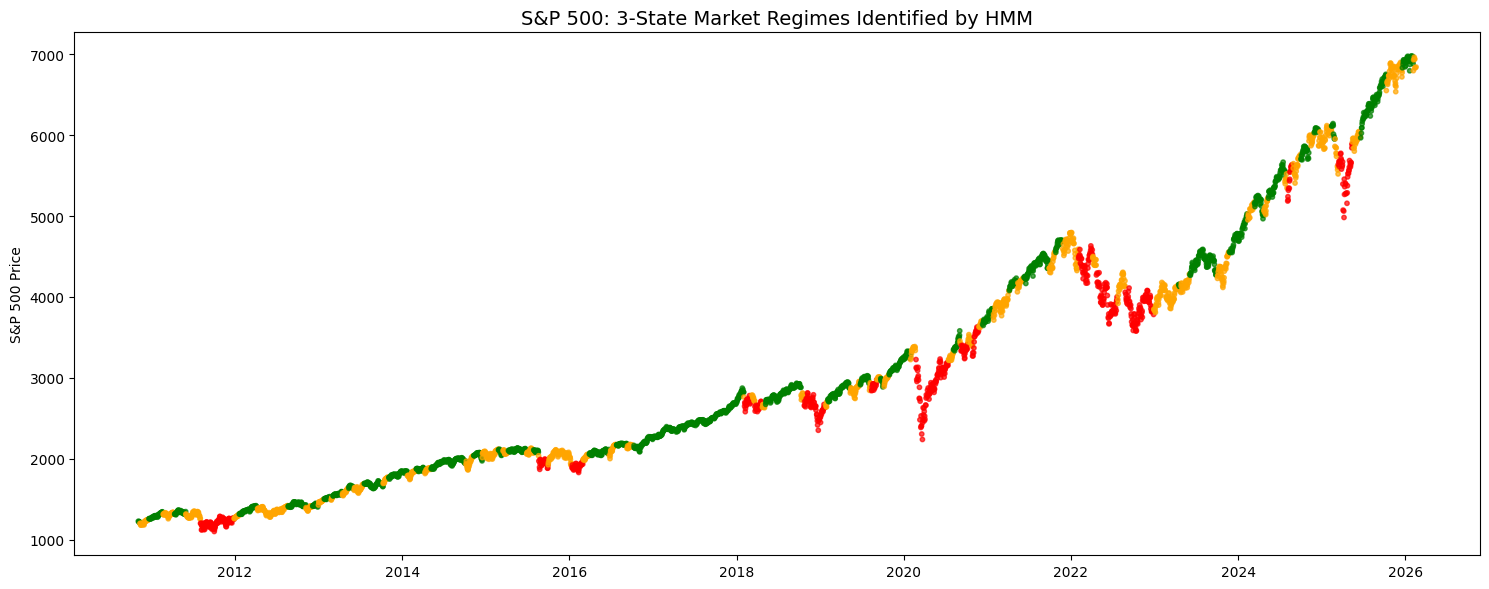

In [5]:
# 📊 Plotting the 3 Regimes
fig, ax = plt.subplots(figsize=(15, 6))

# Use distinct colors for the 3 states
color_map = {
    sorted_regimes[0][0]: 'green',   # Quiet
    sorted_regimes[1][0]: 'orange',  # Choppy
    sorted_regimes[2][0]: 'red'      # Extreme
}
colors = [color_map[x] for x in df['regime']]

ax.scatter(df.index, df['close'], c=colors, s=10, alpha=0.7)
ax.set_title('S&P 500: 3-State Market Regimes Identified by HMM', fontsize=14)
ax.set_ylabel('S&P 500 Price')
plt.tight_layout()
plt.show()